# Módulo 2 — Clase 3: Comparación regional con la API del Banco Mundial

**Curso:** Python y Políticas Públicas  
**Nivel:** Avanzado  
**Duración estimada:** 90 minutos

---

## Objetivos de la clase

Al finalizar esta clase podrás:

- Consumir la API pública del Banco Mundial para obtener datos macroeconómicos y sociales
- Construir funciones reutilizables para descarga y procesamiento de datos
- Generar visualizaciones comparativas entre países de América Latina
- Interpretar la posición relativa de Argentina en la región desde una perspectiva de política pública

---

## La API del Banco Mundial (World Bank API v2)

El Banco Mundial ofrece una API REST pública y **sin necesidad de clave de acceso** que provee miles de indicadores para todos los países del mundo.

**URL base:**
```
https://api.worldbank.org/v2/country/{países}/indicator/{indicador}?format=json&date={inicio}:{fin}&per_page=500
```

**Indicadores que usaremos:**

| Código | Descripción |
|--------|-------------|
| `NY.GDP.PCAP.CD` | PIB per cápita (USD corrientes) |
| `SH.DYN.MORT` | Mortalidad infantil (por 1.000 nacidos vivos) |
| `SL.UEM.TOTL.ZS` | Tasa de desempleo (% de la fuerza laboral) |
| `SE.ADT.LITR.ZS` | Tasa de alfabetización adultos (%) |
| `SP.DYN.LE00.IN` | Esperanza de vida al nacer (años) |
| `SP.POP.TOTL` | Población total |

> **Nota metodológica:** Los datos del Banco Mundial tienen rezagos de publicación. Es común que el dato más reciente disponible tenga 1-2 años de rezago.

In [1]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install requests pandas matplotlib seaborn

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Paleta de identidad del curso ---
C = ['#2A6496', '#E07B3F', '#3D9970', '#8E5EA2', '#C0A830', '#637A8A']

mpl.rcParams.update({
    'figure.figsize'       : (10, 5),
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'normal',
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'legend.frameon'       : False,
    'axes.prop_cycle'      : mpl.cycler(color=C),
    'figure.dpi'           : 110,
})

def tit(ax, t, **kw):
    """Título sin negrita, alineado a la izquierda."""
    ax.set_title(t, loc='left', fontweight='normal', **kw)


In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilos para los gráficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Bibliotecas importadas correctamente.")

Bibliotecas importadas correctamente.


---

## 1. Función auxiliar: `get_wb_indicator()`

Antes de descargar datos, construimos una función reutilizable que:

1. Arma la URL con los parámetros recibidos
2. Hace el request a la API
3. Maneja errores de red y de formato
4. Devuelve un `DataFrame` limpio con columnas estandarizadas

La respuesta de la API tiene el formato:
```json
[{"page": 1, "total": 230, ...}, [{"country": {"value": "Argentina"}, "date": "2022", "value": 14261.8}, ...]]
```

El primer elemento es metadatos; el segundo es la lista de observaciones.

In [4]:
BASE_URL = "https://api.worldbank.org/v2/country/{countries}/indicator/{indicator}"

# Países de América Latina seleccionados
LATAM_COUNTRIES = "ARG;BRA;CHL;MEX;COL;URY;PER;BOL;PRY;ECU"

# Nombres en español para los países
COUNTRY_NAMES_ES = {
    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Chile": "Chile",
    "Mexico": "México",
    "Colombia": "Colombia",
    "Uruguay": "Uruguay",
    "Peru": "Perú",
    "Bolivia": "Bolivia",
    "Paraguay": "Paraguay",
    "Ecuador": "Ecuador"
}


def get_wb_indicator(indicator: str, countries: str = LATAM_COUNTRIES,
                     start: int = 2000, end: int = 2022) -> pd.DataFrame:
    """
    Descarga un indicador del Banco Mundial para un conjunto de países.
    
    Parámetros
    ----------
    indicator : str
        Código del indicador (ej: 'NY.GDP.PCAP.CD')
    countries : str
        Códigos ISO2 de países separados por punto y coma (ej: 'ARG;BRA;CHL')
    start : int
        Año de inicio del período
    end : int
        Año de fin del período
    
    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas: country_code, country, year, value
    """
    url = BASE_URL.format(countries=countries, indicator=indicator)
    params = {
        "format": "json",
        "date": f"{start}:{end}",
        "per_page": 500
    }
    
    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
    except requests.exceptions.ConnectionError:
        print(f"Error: No se pudo conectar con la API del Banco Mundial.")
        return pd.DataFrame()
    except requests.exceptions.Timeout:
        print(f"Error: La solicitud excedió el tiempo de espera (30 segundos).")
        return pd.DataFrame()
    except requests.exceptions.HTTPError as e:
        print(f"Error HTTP {response.status_code}: {e}")
        return pd.DataFrame()
    
    data = response.json()
    
    # Verificar que la respuesta tiene el formato esperado
    if not isinstance(data, list) or len(data) < 2:
        print(f"Error: Respuesta inesperada de la API para el indicador {indicator}.")
        return pd.DataFrame()
    
    records = data[1]
    if records is None:
        print(f"Advertencia: No se encontraron datos para el indicador {indicator}.")
        return pd.DataFrame()
    
    # Parsear los registros
    rows = []
    for record in records:
        if record.get("value") is not None:  # Excluir valores nulos
            rows.append({
                "country_code": record["countryiso3code"],
                "country": COUNTRY_NAMES_ES.get(record["country"]["value"],
                                                 record["country"]["value"]),
                "year": int(record["date"]),
                "value": float(record["value"])
            })
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["country", "year"]).reset_index(drop=True)
    
    return df


# --- Prueba rápida de la función ---
print("Descargando datos de prueba (PIB per cápita, últimos 5 años)...")
df_test = get_wb_indicator("NY.GDP.PCAP.CD", start=2018, end=2022)

if not df_test.empty:
    print(f"Datos descargados: {len(df_test)} observaciones")
    display(df_test.head(10))
else:
    print("No se pudieron obtener datos. Verificar conexión a internet.")

Descargando datos de prueba (PIB per cápita, últimos 5 años)...
Datos descargados: 50 observaciones


,country_code,country,year,value
0,ARG,Argentina,2018,11752.799892
1,ARG,Argentina,2019,9955.974787
2,ARG,Argentina,2020,8535.599380
3,ARG,Argentina,2021,10738.017922
4,ARG,Argentina,2022,13962.189409
5,BOL,Bolivia,2018,4206.855294
6,BOL,Bolivia,2019,4203.154929
7,BOL,Bolivia,2020,3580.967618
8,BOL,Bolivia,2021,4010.760537
9,BOL,Bolivia,2022,4219.461137


---

## 2. Descarga de indicadores para el período 2000–2022

Ahora descargamos los tres indicadores principales que usaremos para el análisis comparativo. Almacenamos cada uno en un diccionario para mantener el código organizado.

In [5]:
# Diccionario de indicadores a descargar
INDICADORES = {
    "pib_percapita":    ("NY.GDP.PCAP.CD", "PIB per cápita (USD corrientes)"),
    "mort_infantil":    ("SH.DYN.MORT",    "Mortalidad infantil (por 1.000 NV)"),
    "desempleo":        ("SL.UEM.TOTL.ZS", "Tasa de desempleo (%)"),
    "esperanza_vida":   ("SP.DYN.LE00.IN", "Esperanza de vida al nacer (años)"),
    "poblacion":        ("SP.POP.TOTL",     "Población total")
}

# Descarga de todos los indicadores
datos = {}
for nombre, (codigo, descripcion) in INDICADORES.items():
    print(f"Descargando: {descripcion}...", end=" ")
    df = get_wb_indicator(codigo, start=2000, end=2022)
    datos[nombre] = df
    if not df.empty:
        print(f"{len(df)} observaciones obtenidas.")
    else:
        print("SIN DATOS.")

print("\nDescarga completada.")

Descargando: PIB per cápita (USD corrientes)... 

230 observaciones obtenidas.
Descargando: Mortalidad infantil (por 1.000 NV)... 

230 observaciones obtenidas.
Descargando: Tasa de desempleo (%)... 

230 observaciones obtenidas.
Descargando: Esperanza de vida al nacer (años)... 

230 observaciones obtenidas.
Descargando: Población total... 

230 observaciones obtenidas.

Descarga completada.


---

## 3. Tabla resumen: últimos valores disponibles

Construimos una tabla con el **valor más reciente disponible** para cada país e indicador. Esto nos permite hacer una comparación de corte transversal.

In [6]:
def ultimo_valor(df: pd.DataFrame, col_nombre: str) -> pd.DataFrame:
    """Extrae el último valor disponible por país."""
    return (
        df.sort_values("year")
          .groupby("country", as_index=False)
          .last()[["country", "year", "value"]]
          .rename(columns={"value": col_nombre, "year": f"año_{col_nombre}"})
    )

# Obtener últimos valores para cada indicador
df_pib  = ultimo_valor(datos["pib_percapita"],  "pib_percapita")
df_mort = ultimo_valor(datos["mort_infantil"],   "mort_infantil")
df_demp = ultimo_valor(datos["desempleo"],       "desempleo")
df_ev   = ultimo_valor(datos["esperanza_vida"],  "esperanza_vida")
df_pob  = ultimo_valor(datos["poblacion"],       "poblacion")

# Merge de todos los indicadores
tabla = df_pib[["country", "pib_percapita"]].copy()
for df_ind, col in [(df_mort, "mort_infantil"), (df_demp, "desempleo"),
                    (df_ev, "esperanza_vida"), (df_pob, "poblacion")]:
    tabla = tabla.merge(df_ind[["country", col]], on="country", how="outer")

# Ordenar por PIB per cápita descendente
tabla = tabla.sort_values("pib_percapita", ascending=False).reset_index(drop=True)
tabla.index = tabla.index + 1  # Ranking desde 1

# Formatear para visualización
tabla_display = tabla.copy()
tabla_display["pib_percapita"] = tabla_display["pib_percapita"].map("${:,.0f}".format)
tabla_display["mort_infantil"] = tabla_display["mort_infantil"].map("{:.1f}".format)
tabla_display["desempleo"]     = tabla_display["desempleo"].map("{:.1f}%".format)
tabla_display["esperanza_vida"] = tabla_display["esperanza_vida"].map("{:.1f}".format)
tabla_display["poblacion"]      = tabla_display["poblacion"].map("{:,.0f}".format)

tabla_display.columns = ["País", "PIB per cápita", "Mort. infantil",
                          "Desempleo", "Esp. de vida", "Población"]

print("Tabla resumen — Últimos valores disponibles por país")
print("(Ordenada por PIB per cápita, mayor a menor)")
display(tabla_display)

Tabla resumen — Últimos valores disponibles por país
(Ordenada por PIB per cápita, mayor a menor)


,País,PIB per cápita,Mort. infantil,Desempleo,Esp. de vida,Población
1,Uruguay,"$20,819",7.3,7.9%,76.5,"3,390,913"
2,Chile,"$15,406",6.8,8.2%,79.2,"19,553,036"
3,Argentina,"$13,962",9.9,6.8%,75.8,"45,407,904"
4,México,"$11,406",13.8,3.3%,74.0,"128,613,117"
5,Brasil,"$9,281",14.6,9.2%,74.9,"210,306,415"
6,Perú,"$7,351",13.7,4.3%,76.8,"33,475,438"
7,Colombia,"$6,680",12.3,10.5%,76.5,"51,737,944"
8,Ecuador,"$6,516",13.2,3.7%,76.6,"17,823,897"
9,Paraguay,"$6,206",17.5,6.8%,72.3,"6,760,464"
10,Bolivia,"$4,219",17.3,3.6%,67.4,"12,077,154"


---

## 4. Evolución del PIB per cápita (2000–2022)

Graficamos la trayectoria del PIB per cápita para cinco países seleccionados, con Argentina destacada.

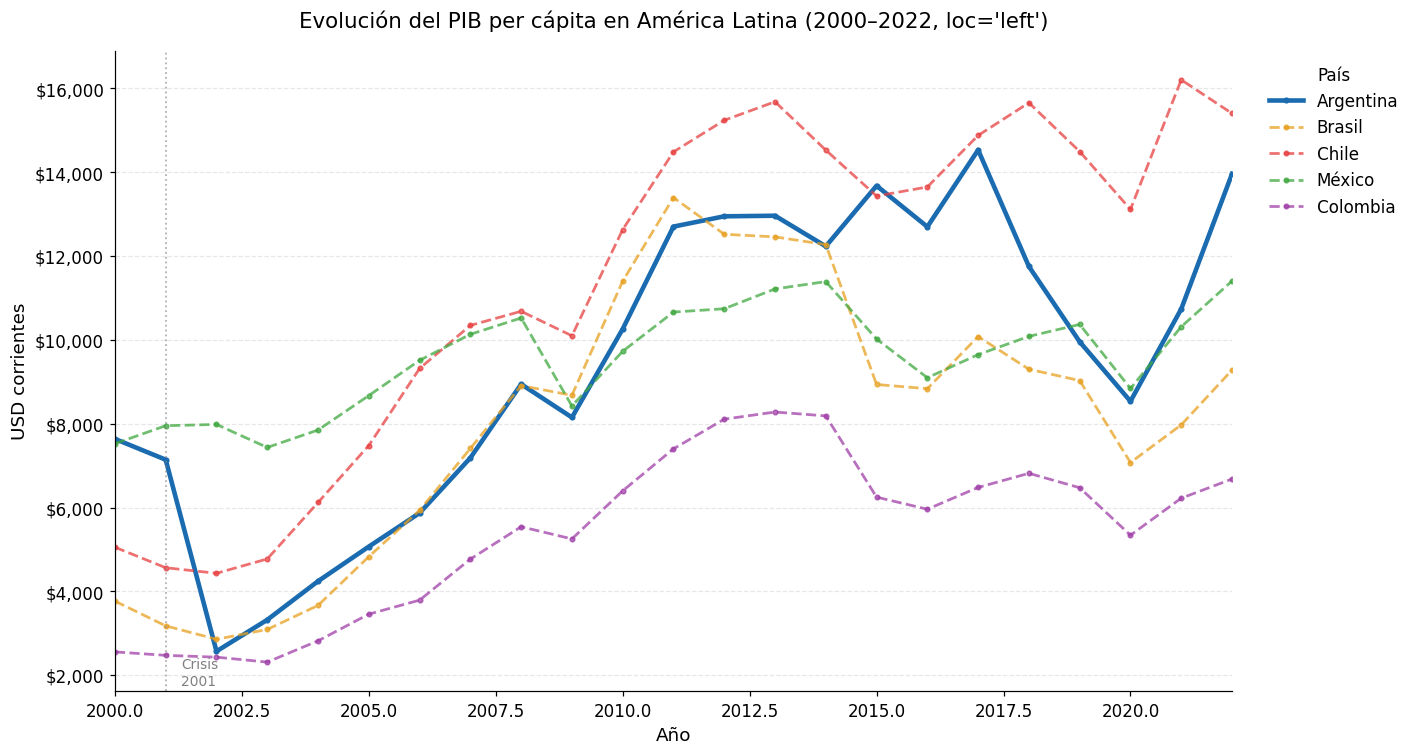


Observación: Los valores en USD corrientes son sensibles a variaciones del tipo de cambio.
En países con alta inflación (como Argentina), las caídas pronunciadas reflejan
devaluaciones del tipo de cambio, no necesariamente contracciones reales de la economía.


In [7]:
# Países a comparar y sus estilos de línea
PAISES_SELECCIONADOS = ["Argentina", "Brasil", "Chile", "México", "Colombia"]
COLORES = {
    "Argentina":  "#1a6baf",   # Azul prominente
    "Brasil":     "#e8a020",
    "Chile":      "#e84040",
    "México":     "#40a840",
    "Colombia":   "#a040a8"
}

df_pib_evol = datos["pib_percapita"].copy()
df_pib_sel  = df_pib_evol[df_pib_evol["country"].isin(PAISES_SELECCIONADOS)]

fig, ax = plt.subplots(figsize=(13, 7))

for pais in PAISES_SELECCIONADOS:
    df_p = df_pib_sel[df_pib_sel["country"] == pais].sort_values("year")
    lw = 3.0 if pais == "Argentina" else 1.8
    ls = "-"  if pais == "Argentina" else "--"
    alpha = 1.0 if pais == "Argentina" else 0.75
    ax.plot(df_p["year"], df_p["value"],
            label=pais, color=COLORES[pais],
            linewidth=lw, linestyle=ls, alpha=alpha, marker="o", markersize=3)

# Anotación del año de crisis 2001 en Argentina
ax.axvline(x=2001, color="gray", linestyle=":", alpha=0.6, linewidth=1.2)
ax.text(2001.3, ax.get_ylim()[0] * 1.05, "Crisis\n2001",
        fontsize=9, color="gray", va="bottom")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("USD corrientes", fontsize=12)
ax.set_title("Evolución del PIB per cápita en América Latina (2000–2022, loc='left')",
             fontsize=14, pad=15)
ax.legend(title="País", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_xlim(2000, 2022)

plt.tight_layout()
plt.show()

print("\nObservación: Los valores en USD corrientes son sensibles a variaciones del tipo de cambio.")
print("En países con alta inflación (como Argentina), las caídas pronunciadas reflejan")
print("devaluaciones del tipo de cambio, no necesariamente contracciones reales de la economía.")


---

## 5. Scatter: PIB per cápita vs. Mortalidad infantil

Este tipo de gráfico de dispersión es clásico en el análisis de desarrollo humano (ver trabajos de Hans Rosling / Gapminder). El tamaño de cada burbuja representa la población del país.

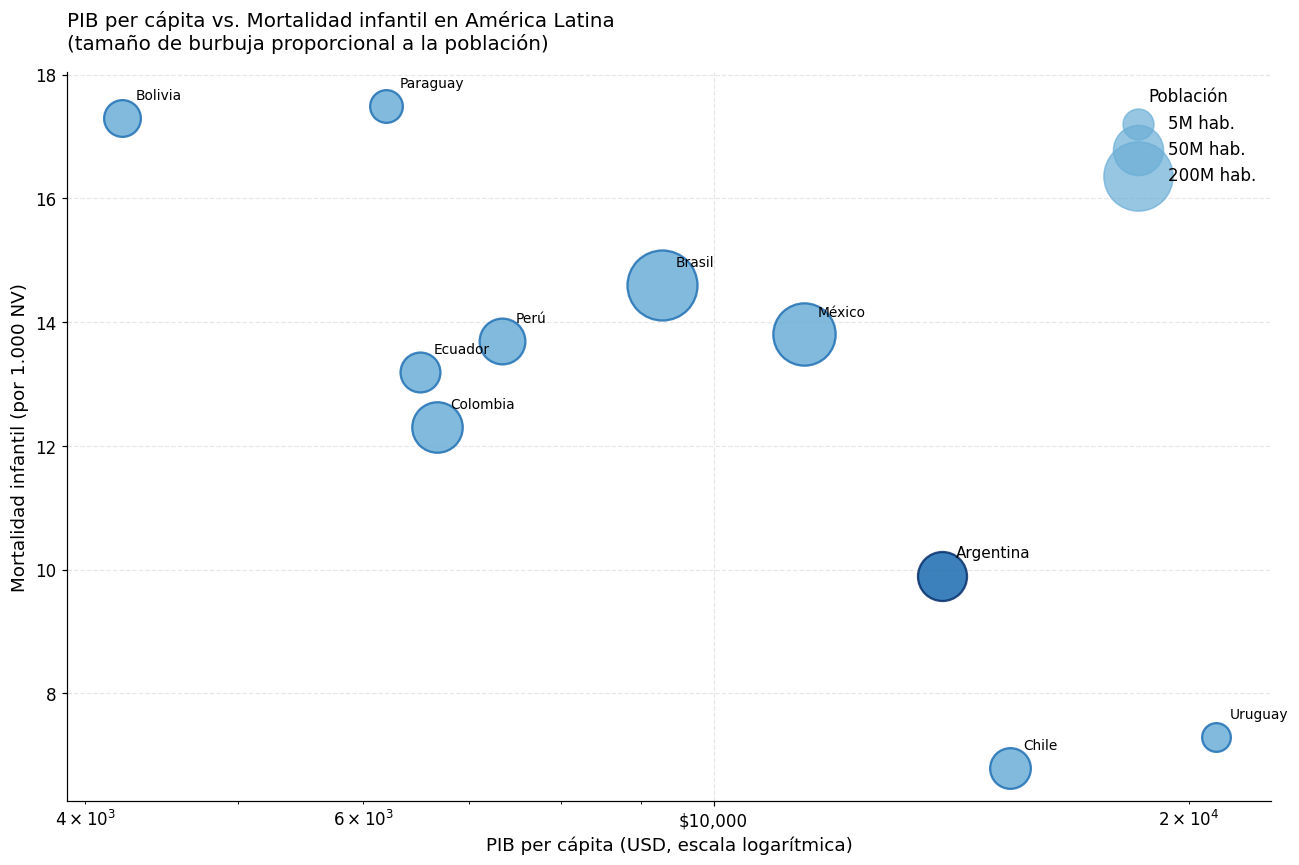


Este gráfico ilustra la correlación negativa entre ingreso y mortalidad infantil.
¿Dónde se ubica Argentina? ¿Es la posición consistente con su nivel de desarrollo?


In [8]:
# Preparar datos para el scatter (últimos valores)
df_scatter = tabla.dropna(subset=["pib_percapita", "mort_infantil", "poblacion"]).copy()
df_scatter = df_scatter.reset_index(drop=True)

# Escalar la población para el tamaño de las burbujas
# Usamos raíz cuadrada para evitar que Brasil y México dominen visualmente
sizes = (df_scatter["poblacion"] / df_scatter["poblacion"].max()) ** 0.5 * 2000 + 100

fig, ax = plt.subplots(figsize=(12, 8))

# Graficar cada país
for idx, row in df_scatter.iterrows():
    color = "#1a6baf" if row["country"] == "Argentina" else "#6baed6"
    edge  = "#08306b" if row["country"] == "Argentina" else "#2171b5"
    ax.scatter(row["pib_percapita"], row["mort_infantil"],
               s=sizes[idx], color=color, edgecolors=edge,
               linewidths=1.5, alpha=0.85, zorder=3)
    # Etiqueta de país
    offset_x = row["pib_percapita"] * 0.02
    ax.annotate(row["country"],
                xy=(row["pib_percapita"], row["mort_infantil"]),
                xytext=(row["pib_percapita"] + offset_x, row["mort_infantil"] + 0.3),
                fontsize=10 if row["country"] == "Argentina" else 9)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("PIB per cápita (USD, escala logarítmica)", fontsize=12)
ax.set_ylabel("Mortalidad infantil (por 1.000 NV)", fontsize=12)
ax.set_title("PIB per cápita vs. Mortalidad infantil en América Latina\n"
             "(tamaño de burbuja proporcional a la población)",
             fontsize=13, pad=15, loc="left")
ax.grid(alpha=0.3, linestyle="--")

# Referencia del tamaño de burbujas
for pob_ref, label in [(5e6, "5M hab."), (50e6, "50M hab."), (200e6, "200M hab.")]:
    size_ref = (pob_ref / df_scatter["poblacion"].max()) ** 0.5 * 2000 + 100
    ax.scatter([], [], s=size_ref, color="#6baed6", alpha=0.7, label=label)
ax.legend(title="Población", loc="upper right", frameon=False, framealpha=0.9)

plt.tight_layout()
plt.show()

print("\nEste gráfico ilustra la correlación negativa entre ingreso y mortalidad infantil.")
print("¿Dónde se ubica Argentina? ¿Es la posición consistente con su nivel de desarrollo?")


---

## 6. Ranking de Argentina en América Latina

Para cada indicador, calculamos la posición de Argentina entre los 10 países de la región.

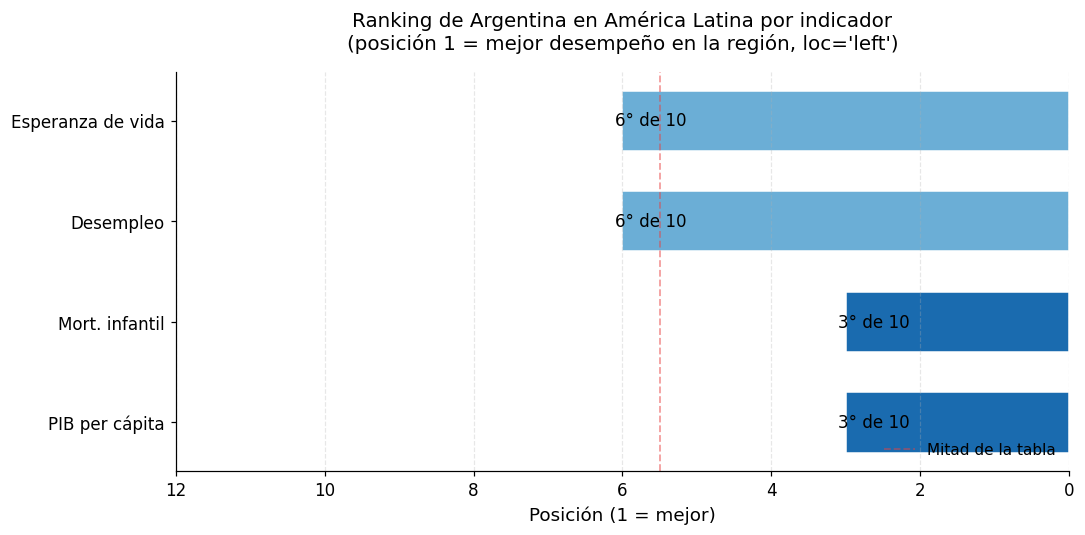


Nota: posición 1 indica el mejor desempeño relativo en la región.
Para mortalidad infantil y desempleo, 'mejor' significa valores más bajos.


In [9]:
# Calcular rankings (1 = mejor posición para cada indicador)
def calcular_ranking(df_tabla: pd.DataFrame, indicador: str,
                     mejor_es_mayor: bool = True) -> dict:
    """
    Calcula el ranking de Argentina para un indicador dado.
    mejor_es_mayor=True: valores más altos son mejor (ej: PIB, esperanza de vida)
    mejor_es_mayor=False: valores más bajos son mejor (ej: mortalidad, desempleo)
    """
    df_temp = df_tabla[["country", indicador]].dropna().copy()
    df_temp["rank"] = df_temp[indicador].rank(ascending=not mejor_es_mayor).astype(int)
    total = len(df_temp)
    
    fila_arg = df_temp[df_temp["country"] == "Argentina"]
    if fila_arg.empty:
        return {"rank": None, "total": total, "valor": None}
    
    return {
        "rank": int(fila_arg["rank"].values[0]),
        "total": total,
        "valor": float(fila_arg[indicador].values[0])
    }

# Calcular rankings para cada indicador
rankings_config = [
    ("pib_percapita",  "PIB per cápita",       True),
    ("mort_infantil",  "Mort. infantil",        False),
    ("desempleo",      "Desempleo",             False),
    ("esperanza_vida", "Esperanza de vida",     True),
]

ranking_arg = []
for col, label, mejor_mayor in rankings_config:
    r = calcular_ranking(tabla, col, mejor_mayor)
    if r["rank"] is not None:
        ranking_arg.append({
            "Indicador": label,
            "Posición": r["rank"],
            "De": r["total"]
        })

df_ranking = pd.DataFrame(ranking_arg)

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 5))

colores_barra = ["#1a6baf" if p <= 3 else "#6baed6" if p <= 6 else "#bdd7e7"
                 for p in df_ranking["Posición"]]

bars = ax.barh(df_ranking["Indicador"], df_ranking["Posición"],
               color=colores_barra, edgecolor="white", height=0.6)

# Anotaciones
for bar, (_, row) in zip(bars, df_ranking.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{int(row['Posición'])}° de {int(row['De'])}",
            va="center", ha="left", fontsize=11)

ax.set_xlim(0, 12)
ax.set_xlabel("Posición (1 = mejor)", fontsize=12)
ax.set_title("Ranking de Argentina en América Latina por indicador\n"
             "(posición 1 = mejor desempeño en la región, loc='left')",
             fontsize=13, pad=15)
ax.axvline(x=5.5, color="#e84040", linestyle="--", alpha=0.5, linewidth=1.2,
           label="Mitad de la tabla")
ax.legend(fontsize=10, loc="lower right", frameon=False)
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.invert_xaxis()

plt.tight_layout()
plt.show()

print("\nNota: posición 1 indica el mejor desempeño relativo en la región.")
print("Para mortalidad infantil y desempleo, 'mejor' significa valores más bajos.")


---

## 7. ¿Qué nos dice la posición relativa de Argentina?

> **Policy brief — Análisis interpretativo**

A continuación reflexionamos sobre lo que los datos revelan desde una perspectiva de política pública.

In [10]:
# Calculamos estadísticas adicionales para el análisis
if not tabla.empty and "pib_percapita" in tabla.columns:
    pib_arg = tabla.loc[tabla["country"] == "Argentina", "pib_percapita"].values
    pib_prom_region = tabla["pib_percapita"].mean()
    
    if len(pib_arg) > 0:
        print(f"PIB per cápita de Argentina: ${pib_arg[0]:,.0f}")
        print(f"Promedio regional:            ${pib_prom_region:,.0f}")
        print(f"Diferencia vs. promedio:      {((pib_arg[0] / pib_prom_region) - 1) * 100:+.1f}%")

print()

# Comparar mortalidad infantil
if "mort_infantil" in tabla.columns:
    mort_arg = tabla.loc[tabla["country"] == "Argentina", "mort_infantil"].values
    mort_prom = tabla["mort_infantil"].mean()
    if len(mort_arg) > 0:
        print(f"Mortalidad infantil Argentina: {mort_arg[0]:.1f} por 1.000 NV")
        print(f"Promedio regional:             {mort_prom:.1f} por 1.000 NV")

PIB per cápita de Argentina: $13,962
Promedio regional:            $10,185
Diferencia vs. promedio:      +37.1%

Mortalidad infantil Argentina: 9.9 por 1.000 NV
Promedio regional:             12.6 por 1.000 NV


### Análisis interpretativo

**¿Qué nos dice la posición relativa de Argentina?**

**1. La paradoja del desarrollo argentino**

Argentina muestra una tensión estructural característica: sus indicadores sociales (esperanza de vida, alfabetización) son consistentemente mejores que lo que su nivel de PIB per cápita sugeriría. Esto refleja un legado histórico de inversión pública en salud y educación que persiste incluso en períodos de contracción económica.

Sin embargo, esta "ventaja social" coexiste con alta volatilidad macroeconómica: las crisis cambiarias (2002, 2018, 2023) producen caídas abruptas en el PIB per cápita medido en dólares corrientes sin que los indicadores sociales se deterioren proporcionalmente en el corto plazo (aunque sí lo hacen con rezago).

**2. Limitaciones de la medición en USD corrientes**

Para países con alta inflación y regímenes cambiarios complejos como Argentina, el PIB per cápita en USD corrientes es una medida problemática:
- Las devaluaciones producen caídas abruptas que no reflejan contracciones reales del bienestar
- Para comparaciones de poder adquisitivo, es preferible usar **PIB per cápita en PPA** (`NY.GDP.PCAP.PP.CD`)
- El indicador oficial del Banco Mundial se basa en el tipo de cambio oficial, que puede diferir significativamente del tipo de cambio efectivo

**3. Implicancias para el diseño de políticas**

Para el analista de política pública, estos resultados sugieren:
- No usar un único indicador para caracterizar el desarrollo de un país
- Considerar el rezago estadístico: los efectos de políticas implementadas hoy pueden tardar años en aparecer en los datos del Banco Mundial
- La comparación regional debe contextualizarse: Argentina comparte características más parecidas a Uruguay y Chile que a Bolivia o Paraguay

---

> **Para discutir en clase:** ¿Qué indicadores adicionales del Banco Mundial agregarían para tener una imagen más completa del bienestar en Argentina? ¿Cómo cambiaría el análisis si usáramos datos en PPA en lugar de USD corrientes?

---

## Ejercicios

### Ejercicio 1 — Análisis de convergencia

Descargá el indicador de **esperanza de vida** (`SP.DYN.LE00.IN`) para todos los países de LATAM en el período 2000–2022. Luego:

a) Calculá la **brecha** entre el país con mayor y menor esperanza de vida para cada año  
b) Graficá la evolución de esta brecha en el tiempo  
c) ¿Hay evidencia de convergencia (reducción de la brecha)? ¿Qué política pública podría explicarlo?

**Pista:** Usá `.groupby("year")["value"].agg(["max", "min"])` para calcular la brecha anual.

In [11]:
# Tu código aquí


### Ejercicio 2 — Comparación PIB en PPA vs. USD corrientes

El Banco Mundial también provee el PIB per cápita en **Paridad de Poder Adquisitivo (PPA)**, código `NY.GDP.PCAP.PP.CD`. 

a) Descargá ambas series para Argentina (2000–2022)  
b) Calculá el **ratio** PPA/USD para cada año  
c) Graficá ambas series en un gráfico con dos ejes Y  
d) Identificá los años donde la diferencia fue mayor. ¿A qué eventos macroeconómicos corresponden?

**Pista:** Para el segundo eje Y, usá `ax2 = ax.twinx()`.

In [12]:
# Tu código aquí


### Ejercicio 3 — Mapa de calor de correlaciones

Construí un mapa de calor (heatmap) que muestre la correlación entre los cinco indicadores para los datos de corte transversal (últimos valores disponibles).

a) Armá un DataFrame donde cada fila sea un país y cada columna un indicador  
b) Calculá la matriz de correlación con `.corr()`  
c) Visualizala con `matplotlib` (o `seaborn` si lo tenés instalado)  
d) Interpretá la correlación entre PIB per cápita y mortalidad infantil. ¿Es la dirección esperada? ¿Qué magnitud tiene?

**Pista:** Para el heatmap con matplotlib: `ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)`.

In [13]:
# Tu código aquí
